# Module 2 — Fugacity, and the criterion it makes arithmetic

**2105603 Advanced Chemical Engineering Thermodynamics**
Department of Chemical Engineering, Chulalongkorn University
Soorathep Kheawhom

---

Chemical potential is the true driving force for mass transfer. It is also
unusable in raw form: it is not measurable, and it diverges to $-\infty$ at zero
pressure, so there is nowhere to put a reference state. Fugacity is the quantity
constructed to fix exactly that, and nothing else.

This notebook does five things:

| step | question |
|---|---|
| 1 | show numerically that $\mu$ has no bottom, and that $f$ does |
| 2 | get $\varphi$ out of an equation of state, by two routes that share no code |
| 3 | build the fugacity of a liquid, and say when Poynting stops being ignorable |
| 4 | **prove** the Maxwell equal-area construction from $f^{\,L} = f^{\,V}$ |
| 5 | get Clapeyron out of the same statement, differentiated instead of integrated |

Module 1 handed you the equal-area construction as a recipe and asked you to
accept it. Step 4 is the payment of that debt.

**Rule for this notebook, as for every notebook in this course.** Every number
you report must be reproduced by an independent route. Where the two routes are
secretly the same equation — and in step 4 they are — say so, and say what the
agreement does and does not prove.

## 0. Setup

In [1]:
import sys, subprocess, importlib, importlib.util, os

def ensure(pkg, pipname=None):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        pipname or pkg], check=False)

for p in ("numpy", "scipy", "matplotlib"):
    ensure(p)

if not os.path.isdir("vlekit") and importlib.util.find_spec("vlekit") is None:
    import urllib.request, zipfile, io
    URL = "https://www.skhgroup.net/teaching/2105603/files/vlekit.zip"
    try:
        with urllib.request.urlopen(URL, timeout=30) as r:
            zipfile.ZipFile(io.BytesIO(r.read())).extractall(".")
        print("downloaded vlekit from the course page")
    except Exception as e:
        print("could not download vlekit:", e)

import numpy as np
import matplotlib.pyplot as plt
import vlekit as v
from vlekit import cubic as C, data as D, plots as pl

pl.use_style()
R = C.R                      # 8.314462618 J/mol/K; pressures in kPa throughout
print("vlekit", v.__version__, " R =", R, "J/mol/K")

vlekit 0.1.0  R = 8.314462618 J/mol/K


## 1. Chemical potential has no bottom

For an ideal gas $\left(\partial\mu/\partial P\right)_T = v = RT/P$, so

$$\mu(T,P) - \mu^\circ(T,P^\circ) = RT\ln\frac{P}{P^\circ}.$$

Every factor of ten you take off the pressure subtracts another $RT\ln 10$, and
nothing stops it. That is not a numerical inconvenience; it is a statement that
an infinitely dilute gas has unboundedly negative chemical potential, because
there is unbounded entropy available in expanding into nothing.

Below, the ideal-gas expression $RT\ln(P/P^\circ)$ is tabulated for n-butane at
350 K against the **ideal-gas standard state at $P^\circ = 100$ kPa** — that
reference is stated here and used for the rest of the section. Alongside it are
the real-fluid fugacity $f = \varphi P$ from Peng-Robinson and the ratio $f/P$.
For the real fluid the same difference is $RT\ln(f/P^\circ)$, which is the
tabulated column plus $RT\ln\varphi$; at 1 kPa that correction is half a joule
per mole, which is the point.

In [2]:
c = v.component("n-butane")                    # library entry, SVA/Yaws + Poling
pr = C.PengRobinson([c])                       # pure fluid; k_ij is irrelevant
T = 350.0
P0 = 100.0                                     # the stated reference pressure

print(f"n-butane at {T:.0f} K, Peng-Robinson (1976 alpha), omega = {c.omega}")
print(f"{'P / kPa':>10} {'RT ln(P/P0) / J/mol':>21} {'phi':>16} "
      f"{'f / kPa':>12} {'f / P':>16}")
for P in (1e2, 1e0, 1e-2, 1e-4, 1e-6, 1e-8):
    lnphi, Z = pr.ln_phi(T, P, [1.0], phase="vapour")
    phi = float(np.exp(lnphi[0]))
    print(f"{P:10.0e} {R*T*np.log(P/P0):21.1f} {phi:16.12f} "
          f"{phi*P:12.3e} {phi:16.12f}")

print(f"\nevery decade down costs another RT ln 10 = {R*T*np.log(10):.1f} J/mol,")
print("and the column never turns round.  f, by contrast, goes to zero and f/P")
print("goes to one — which is exactly the condition the definition imposes.")

n-butane at 350 K, Peng-Robinson (1976 alpha), omega = 0.2
   P / kPa   RT ln(P/P0) / J/mol              phi      f / kPa            f / P
     1e+02                   0.0   0.982488101160    9.825e+01   0.982488101160
     1e+00              -13401.3   0.999824367175    9.998e-01   0.999824367175
     1e-02              -26802.7   0.999998243619    1.000e-02   0.999998243619
     1e-04              -40204.0   0.999999982436    1.000e-04   0.999999982436
     1e-06              -53605.3   0.999999999824    1.000e-06   0.999999999824
     1e-08              -67006.7   0.999999999998    1.000e-08   0.999999999998

every decade down costs another RT ln 10 = 6700.7 J/mol,
and the column never turns round.  f, by contrast, goes to zero and f/P
goes to one — which is exactly the condition the definition imposes.


The $f/P \to 1$ column is the definition asserting itself, but "it looks like
one" is not a check. The check is the *rate* at which it approaches one. For
Peng-Robinson the second virial coefficient is available in closed form,
$B_2 = b - a/RT$, and at low pressure $\ln\varphi \to B_2 P / RT$.

In [3]:
x = np.array([1.0])
a, b = pr.a_mix(T, x), pr.b_mix(x)
B2 = b - a / (R * T)                  # PR's own second virial coefficient
print(f"B2 from Peng-Robinson      : {B2*1e6:9.2f} cm3/mol")
print(f"B2 from Pitzer-Tsonopoulos : {c.B_virial(T)*1e6:9.2f} cm3/mol"
      "   <- a different correlation, so a different number")

for P in (1e-2, 1e-4):
    lnphi, _ = pr.ln_phi(T, P, x, phase="vapour")
    lim = B2 * P * 1e3 / (R * T)
    print(f"P = {P:8.0e} kPa:  ln phi = {lnphi[0]:.6e},  "
          f"B2 P/RT = {lim:.6e},  ratio = {lnphi[0]/lim:.9f}")

B2 from Peng-Robinson      :   -511.12 cm3/mol
B2 from Pitzer-Tsonopoulos :   -497.23 cm3/mol   <- a different correlation, so a different number
P =    1e-02 kPa:  ln phi = -1.756382e-06,  B2 P/RT = -1.756381e-06,  ratio = 1.000000577
P =    1e-04 kPa:  ln phi = -1.756381e-08,  B2 P/RT = -1.756381e-08,  ratio = 1.000000023


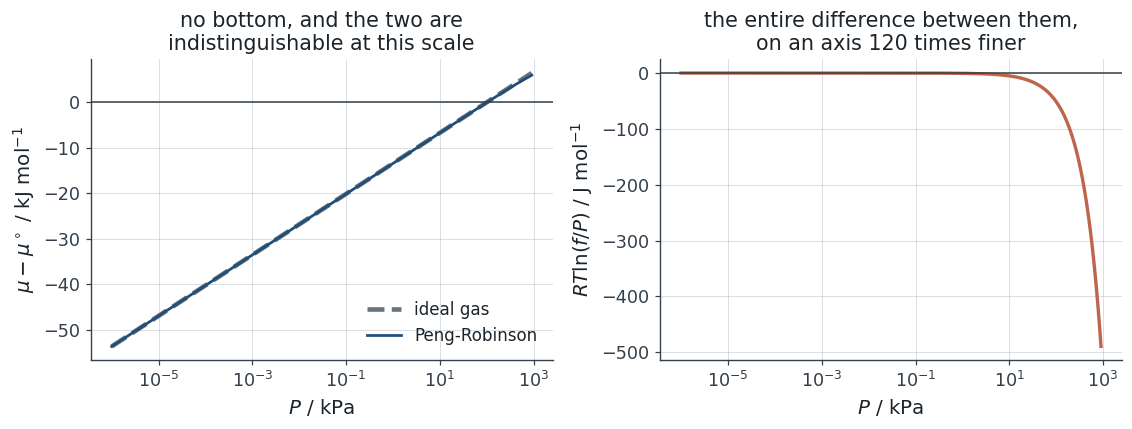

separation at 900 kPa : -489.4 J/mol
range of the left axis: 60.0 kJ/mol
the first is 0.82 % of the second, which is why the left panel shows one line.
The right panel is that difference and nothing else. It vanishes at low
P by construction, and it is the whole of what fugacity was invented for.


In [4]:
Ps = np.logspace(-6, np.log10(900.0), 250)     # 900 kPa is below Psat at 350 K
lnphis = np.array([pr.ln_phi(T, P, x, phase="vapour")[0][0] for P in Ps])
mu_ideal = R * T * np.log(Ps / P0)
mu_real = mu_ideal + R * T * lnphis

pl.use_style()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.0))
for ax in (a1, a2):
    ax.grid(True); ax.set_axisbelow(True); ax.set_xlabel("$P$ / kPa")
a1.semilogx(Ps, mu_ideal/1e3, "--", color=pl.SLATE, lw=3.0, label="ideal gas")
a1.semilogx(Ps, mu_real/1e3, "-", color=pl.NAVY, lw=1.8, label="Peng-Robinson")
a1.axhline(0, color=pl.GRAPHITE, lw=1.0)
a1.set_ylabel(r"$\mu-\mu^\circ$ / kJ mol$^{-1}$")
a1.set_title("no bottom, and the two are\nindistinguishable at this scale")
a1.legend(loc="lower right")
a2.semilogx(Ps, R*T*lnphis, "-", color=pl.RUST, lw=2.2)
a2.axhline(0, color=pl.GRAPHITE, lw=1.0)
a2.set_ylabel(r"$RT\ln(f/P)$ / J mol$^{-1}$")
a2.set_title("the entire difference between them,\non an axis 120 times finer")
fig.tight_layout(); plt.show()

span = (mu_ideal.max() - mu_ideal.min()) / 1e3
print(f"separation at 900 kPa : {R*T*lnphis[-1]:.1f} J/mol")
print(f"range of the left axis: {span:.1f} kJ/mol")
print(f"the first is {100*abs(R*T*lnphis[-1])/1e3/span:.2f} % of the second, "
      "which is why the left panel shows one line.")
print("The right panel is that difference and nothing else. It vanishes at low")
print("P by construction, and it is the whole of what fugacity was invented for.")

**Question 1.1.** On the left panel the two curves are one line. Using the right
panel, name a pressure below which you would be willing to use the ideal-gas
chemical potential for this fluid — and state the tolerance in J/mol that made
you choose it. The question has no answer until you supply that tolerance.

**Question 1.2.** $RT\ln(f/P)$ is negative everywhere here, so the real curve
lies *below* the ideal one. What would have to be true of $Z$ for it to lie
above, and at what conditions does that happen?

## 2. $\varphi$ from an equation of state, computed twice

Two expressions for the same quantity:

$$\ln\varphi = \int_0^P (Z-1)\,\frac{{\rm d}P}{P}
\qquad\qquad
\ln\varphi = Z - 1 - \ln(Z-B)
 - \frac{A}{2\sqrt2\,B}\,\ln\!\left[\frac{Z+(1+\sqrt2)B}{Z+(1-\sqrt2)B}\right]$$

The right-hand one is what `vlekit.cubic` evaluates: it comes from integrating
over **volume**, which a pressure-explicit cubic can do analytically. The
left-hand one needs $Z(P)$, so every point of the integral costs a cubic solve.
That is why no implementation uses it — and why it is a genuinely independent
route for checking one that does.

Write the integral yourself before you run the next cell. Three points to think
about first:

- the integrand $(Z-1)/P$ is finite at $P=0$ — its limit is $B_2/RT$ — but
  evaluating it *at* zero divides by zero, so the code has to say what it does
  there;
- which root do you take? Below $P^{\rm sat}$ the stable root is the vapour, but
  make the choice explicit rather than letting `select_root` guess;
- `quad` reports its own error estimate. Print it. An agreement that is better
  than the quadrature error is luck, not verification.

In [5]:
from scipy.integrate import quad

def my_ln_phi(mix, T, P, phase="vapour", P_floor=1e-6):
    """Write this yourself before running the cell below.

    ln phi = integral from 0 to P of (Z-1)/P dP, along the isotherm.
    The integrand is finite at P = 0; P_floor just keeps the cubic solver away
    from a pressure at which the roots are pure round-off.
    """
    def integrand(p):
        p = max(p, P_floor)
        Z = mix.select_root(T, p, [1.0], phase=phase)
        return (Z - 1.0) / p
    value, err = quad(integrand, 0.0, P, limit=300)
    return value, err

In [6]:
cases = [("n-butane", 350.0,   900.0, "vapour"),   # below Psat = 946 kPa
         ("methane",  300.0,  5000.0, "vapour"),   # supercritical, one root
         ("methane",  300.0, 20000.0, "vapour")]

print(f"{'fluid':>9} {'T/K':>6} {'P/kPa':>8} {'closed form':>15} "
      f"{'integral':>15} {'difference':>12} {'quad err':>10}")
for name, Tc_, Pc_, ph in cases:
    m = C.PengRobinson([v.component(name)])
    closed = float(m.ln_phi(Tc_, Pc_, [1.0], phase=ph)[0][0])
    num, err = my_ln_phi(m, Tc_, Pc_, phase=ph)
    print(f"{name:>9} {Tc_:6.0f} {Pc_:8.0f} {closed:15.12f} {num:15.12f} "
          f"{num-closed:12.2e} {err:10.1e}")

    fluid    T/K    P/kPa     closed form        integral   difference   quad err
 n-butane    350      900 -0.168190591125 -0.168190591125    -1.94e-16    1.9e-15
  methane    300     5000 -0.103822653413 -0.103822653413     3.19e-16    1.2e-15
  methane    300    20000 -0.324764519304 -0.324764519304    -1.05e-15    1.8e-14


The two routes agree to the last bit of a double, and the difference is smaller
than `quad`'s own error estimate — which is the honest way to say that the
closed-form Peng-Robinson expression in `vlekit.cubic.ln_phi` has been
integrated correctly. Nothing here checks Peng-Robinson against *nature*; it
checks one implementation of a model against another.

**Question 2.1.** Change `phase="vapour"` to `"liquid"` in the n-butane case and
explain the number you get. It is not nonsense, and it is not the vapour answer.

**Question 2.2.** Raise `P_floor` to 1 kPa and re-run. How large does the error
become, and why is it so much smaller than you would guess from the size of the
region you removed?

## 3. The fugacity of a liquid, and when Poynting stops being small

A liquid has no low-pressure limit to be anchored to, so it is anchored to the
vapour it is in equilibrium with:

$$f^{\,L}(T,P) = \underbrace{\varphi^{\rm sat}P^{\rm sat}}_{f\ \text{at saturation}}
\times
\underbrace{\exp\!\left[\frac{v^{\,L}\,(P-P^{\rm sat})}{RT}\right]}_{\text{Poynting}}$$

Two assumptions are being made and both should be said out loud. First, $v^L$ is
taken as constant — the library value near 25 °C — which is the incompressible
approximation; it is the first thing to question once $P - P^{\rm sat}$ becomes
large or $T$ approaches $T_c$. Second, $\varphi^{\rm sat}$ needs a vapour model
at $P^{\rm sat}$, and two different models are used below precisely so that the
difference between them is visible.

"Poynting is usually negligible" is not a statement anyone can act on. The
actionable version is a pressure: **at what $P$ does it first change $f^L$ by one
per cent?** That is just ${\rm PF} = 1.01$, so

$$P - P^{\rm sat} = \frac{RT\ln 1.01}{v^{\,L}} .$$

In [7]:
Tliq = 298.15
print(f"at {Tliq:.2f} K\n")
print(f"{'liquid':>10} {'vL/cm3':>8} {'Psat/kPa':>9} {'phi_sat PR':>11} "
      f"{'phi_sat vir':>12} {'(1-phi) ratio':>14} {'P-Psat/bar':>11} {'P/bar':>8}")
for name in ("water", "ethanol", "n-hexane"):
    cc = v.component(name)
    m = C.PengRobinson([cc])
    Psat = float(cc.Psat(Tliq))
    phis_pr = float(np.exp(m.ln_phi(Tliq, Psat, [1.0], phase="vapour")[0][0]))
    phis_vi = float(D.phi_sat_virial(Tliq, cc))
    dP = np.log(1.01) * R * Tliq / cc.vL / 1e3          # kPa
    print(f"{name:>10} {cc.vL*1e6:8.2f} {Psat:9.4f} {phis_pr:11.6f} "
          f"{phis_vi:12.6f} {(1-phis_vi)/(1-phis_pr):14.2f} "
          f"{dP/100:11.3f} {(Psat+dP)/100:8.3f}")

at 298.15 K

    liquid   vL/cm3  Psat/kPa  phi_sat PR  phi_sat vir  (1-phi) ratio  P-Psat/bar    P/bar
     water    18.07    3.1877    0.999514     0.998765           2.54      13.650   13.682
   ethanol    58.70    7.8954    0.997226     0.995431           1.65       4.202    4.281
  n-hexane   131.60   20.2009    0.988357     0.984079           1.37       1.874    2.076


The point of the last two columns is that there is no single pressure to
memorise. The exponent scales with $v^L$, so water — the smallest molar volume
in the table — tolerates seven times the pressure of n-hexane before the same
one per cent appears.

The two $\varphi^{\rm sat}$ columns are a cubic equation of state and a two-term
virial equation with Pitzer-Tsonopoulos coefficients, sharing no parameters
beyond $T_c$, $P_c$ and $\omega$. They differ by 0.07 % for water and 0.43 % for
n-hexane — small in $\varphi$, but the last column shows that the two models
disagree about the *departure* $1-\varphi$ that each is actually predicting by a
factor of 2.5 and 1.4 respectively. That is the honest way to compare two
corrections: on the correction, not on the corrected quantity.
Both are nearly one at a few kPa and neither is doing much work here. Do not
read the water row as evidence that Peng-Robinson describes water: at these
conditions it is barely being asked a question.

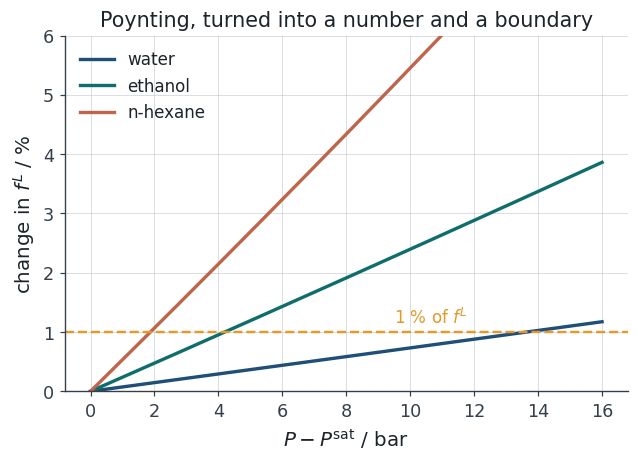

In [8]:
dPs = np.linspace(0.0, 1600.0, 400)            # kPa above saturation
fig, ax = pl.newfig(6.6, 4.2)
for name, col in (("water", pl.NAVY), ("ethanol", pl.TEAL),
                  ("n-hexane", pl.RUST)):
    cc = v.component(name)
    PF = np.exp(cc.vL * dPs * 1e3 / (R * Tliq))
    ax.plot(dPs/100, 100*(PF - 1), "-", color=col, lw=2.2, label=name)
ax.axhline(1.0, color=pl.AMBER, ls="--", lw=1.6)
ax.text(9.5, 1.15, "1 % of $f^L$", color=pl.AMBER, fontsize=11)
ax.set_xlabel(r"$P - P^{\rm sat}$ / bar")
ax.set_ylabel("change in $f^L$ / %")
ax.set_ylim(0, 6); ax.set_title("Poynting, turned into a number and a boundary")
ax.legend(loc="upper left")
plt.show()

**Question 3.1.** You are modelling an absorber at 30 bar and 25 °C with hexane
as the solvent. Quote the error you commit by dropping the Poynting factor, as a
percentage of $f^L$.

**Question 3.2.** Above $T_c$ there is no $P^{\rm sat}$ to anchor to. Write down,
in one sentence, what the "fugacity of the pure liquid" then means — and where in
Module 4 that arbitrariness comes back.

## 4. Equality of fugacity **is** the equal-area construction

Below $T_c$ the cubic has three roots. Two are candidate phases. The criterion
$\mu^L = \mu^V$, with the definition substituted, is

$$f^{\,L}(T,P) = f^{\,V}(T,P)\qquad\Longleftrightarrow\qquad
\varphi^{\,L} = \varphi^{\,V} ,$$

since both are at the same $P$. That is a one-dimensional root find, and it is
what `vlekit.cubic.psat` does.

Module 1 gave you a different rule for the same pressure: draw the horizontal
line on the isotherm that cuts off equal areas,

$$\int_{v^L}^{v^V} P_{\rm EOS}(v)\,{\rm d}v \;=\; P^{\rm sat}\,(v^V - v^L).$$

Compute both. Nothing in the second calculation mentions fugacity, chemical
potential or $\varphi$; it is an area under a curve.

In [9]:
from scipy.optimize import brentq

Tn = 400.0                                # n-butane, Tr = 0.941
prn = C.PengRobinson([v.component("n-butane")])
xn = np.array([1.0])

P_fug = C.psat(prn, 0, Tn)                # route 1: equal fugacity
lnL, ZL = prn.ln_phi(Tn, P_fug, xn, phase="liquid")
lnV, ZV = prn.ln_phi(Tn, P_fug, xn, phase="vapour")
print(f"equal-fugacity pressure : {P_fug:.9f} kPa")
print(f"  f_liquid = {np.exp(lnL[0])*P_fug:.10f} kPa")
print(f"  f_vapour = {np.exp(lnV[0])*P_fug:.10f} kPa")
print(f"  they differ by {abs(np.exp(lnL[0])-np.exp(lnV[0]))*P_fug:.2e} kPa")

equal-fugacity pressure : 2515.706179716 kPa
  f_liquid = 1790.5487704164 kPa
  f_vapour = 1790.5487704037 kPa
  they differ by 1.27e-08 kPa


In [10]:
an, bn = prn.a_mix(Tn, xn), prn.b_mix(xn)

def P_eos(vm):
    """The Peng-Robinson isotherm, P in Pa for v in m3/mol."""
    return R*Tn/(vm - bn) - an/(vm*(vm + bn) + bn*(vm - bn))

def area_residual(P):
    """integral of P dv between the outer roots, minus P dv of the rectangle."""
    Zs = prn.Z_roots(Tn, P, xn)
    if Zs.size < 3:
        return np.nan                     # no two-phase line to draw here
    vL, vV = Zs[0]*R*Tn/(P*1e3), Zs[-1]*R*Tn/(P*1e3)
    I, _ = quad(P_eos, vL, vV, limit=300)
    return I - P*1e3*(vV - vL)

# bracket without using P_fug: scan the pressures at which three roots exist
grid = np.linspace(0.2*prn.Pc[0]/1e3, 0.95*prn.Pc[0]/1e3, 241)
vals = np.array([area_residual(P) for P in grid])
ok = np.isfinite(vals)
g, w = grid[ok], vals[ok]
i = np.where(np.sign(w[:-1]) != np.sign(w[1:]))[0][0]
P_area = brentq(area_residual, g[i], g[i+1], xtol=1e-10, rtol=1e-15)

print(f"three real roots between {g.min():.1f} and {g.max():.1f} kPa")
print(f"equal-area pressure     : {P_area:.9f} kPa")
print(f"equal-fugacity pressure : {P_fug:.9f} kPa")
print(f"difference              : {abs(P_area-P_fug):.2e} kPa "
      f"({abs(P_area-P_fug)/P_fug:.1e} relative)")

three real roots between 1471.0 and 2835.1 kPa
equal-area pressure     : 2515.706179753 kPa
equal-fugacity pressure : 2515.706179716 kPa
difference              : 3.77e-08 kPa (1.5e-11 relative)


**Say precisely what that agreement is.** Along an isotherm
$RT\,{\rm d}\ln f = v\,{\rm d}P$, so

$$RT\ln\frac{f^{\,V}}{f^{\,L}} = \int_{L}^{V} v\,{\rm d}P
= \Big[Pv\Big]_L^V - \int_{v^L}^{v^V} P\,{\rm d}v
= P^{\rm sat}(v^V - v^L) - \int_{v^L}^{v^V} P\,{\rm d}v ,$$

and setting the left side to zero *is* the equal-area statement. The two
calculations above are the same equation reached from opposite ends. The
agreement to $10^{-11}$ relative is therefore a check that **both
implementations are correct** — the closed-form $\ln\varphi$, the root selector,
the quadrature and the two root finders — and it is not independent physical
evidence for either. Claiming more than that would be exactly the overreach this
course spends six modules teaching you to avoid.

What *is* new is the direction of the argument. Module 1 asserted the
construction. Here it has been derived from $\mu^L = \mu^V$, which is the second
law, and nothing else.

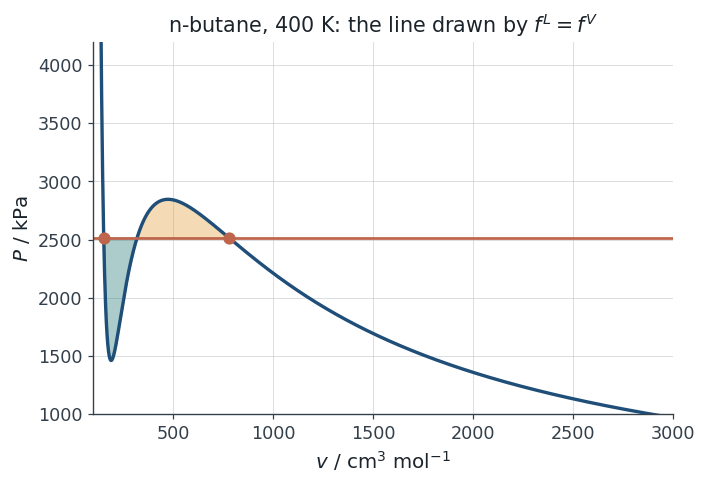

vL = 152.14 cm3/mol, vV = 778.41 cm3/mol


In [11]:
vv = np.linspace(1.02*bn, 5.0e-3, 4000)
Piso = np.array([P_eos(t) for t in vv])/1e3            # kPa
Zs = prn.Z_roots(Tn, P_fug, xn)
vL, vV = Zs[0]*R*Tn/(P_fug*1e3), Zs[-1]*R*Tn/(P_fug*1e3)
inside = (vv >= vL) & (vv <= vV)

fig, ax = pl.newfig(6.8, 4.4)
ax.plot(vv*1e6, Piso, "-", color=pl.NAVY, lw=2.2)
ax.fill_between(vv[inside]*1e6, Piso[inside], P_fug,
                where=Piso[inside] > P_fug, color=pl.AMBER, alpha=0.35)
ax.fill_between(vv[inside]*1e6, Piso[inside], P_fug,
                where=Piso[inside] < P_fug, color=pl.TEAL, alpha=0.35)
ax.axhline(P_fug, color=pl.RUST, lw=1.8)
ax.plot([vL*1e6, vV*1e6], [P_fug, P_fug], "o", color=pl.RUST, ms=7)
ax.set_xlim(100, 3000); ax.set_ylim(1000, 4200)
ax.set_xlabel(r"$v$ / cm$^3$ mol$^{-1}$"); ax.set_ylabel("$P$ / kPa")
ax.set_title("n-butane, 400 K: the line drawn by $f^L = f^V$")
plt.show()
print(f"vL = {vL*1e6:.2f} cm3/mol, vV = {vV*1e6:.2f} cm3/mol")

One honesty check before moving on: is 2515.7 kPa the vapour pressure of
n-butane at 400 K, or only Peng-Robinson's opinion of it? Compare it with the
Antoine correlation carried in the library and with Lee-Kesler, which uses only
$T_c$, $P_c$ and $\omega$ and shares no fitted parameters with either.

In [12]:
cb = v.component("n-butane")
Tr = Tn / cb.Tc
f0 = 5.92714 - 6.09648/Tr - 1.28862*np.log(Tr) + 0.169347*Tr**6
f1 = 15.2518 - 15.6875/Tr - 13.4721*np.log(Tr) + 0.43577*Tr**6
P_LK = np.exp(f0 + cb.omega*f1) * cb.Pc          # Lee-Kesler, Poling et al. eq 7-2.6

print(f"Tr = {Tr:.4f}   (Antoine fit range is {cb.Trange[0]}-{cb.Trange[1]} K)")
print(f"Peng-Robinson : {P_fug:9.1f} kPa")
print(f"Antoine       : {float(cb.Psat(Tn)):9.1f} kPa   "
      f"({100*(float(cb.Psat(Tn))-P_fug)/P_fug:+.1f} % vs PR)")
print(f"Lee-Kesler    : {P_LK:9.1f} kPa   ({100*(P_LK-P_fug)/P_fug:+.1f} % vs PR)")
print("\nTwo of the three agree to well under a per cent and the Antoine fit is")
print("the outlier — which is what an Antoine equation does at Tr = 0.94, near")
print("the top of its range. Do not extrapolate a three-parameter vapour")
print("pressure fit towards the critical point.")

Tr = 0.9409   (Antoine fit range is 196-425 K)
Peng-Robinson :    2515.7 kPa
Antoine       :    2381.0 kPa   (-5.4 % vs PR)
Lee-Kesler    :    2504.7 kPa   (-0.4 % vs PR)

Two of the three agree to well under a per cent and the Antoine fit is
the outlier — which is what an Antoine equation does at Tr = 0.94, near
the top of its range. Do not extrapolate a three-parameter vapour
pressure fit towards the critical point.


## 5. Clapeyron, from the same statement differentiated

$f^L = f^V$ holds *for every $T$* along the saturation line. Differentiate it
along that line and, with ${\rm d}g = -s\,{\rm d}T + v\,{\rm d}P$,

$$\frac{{\rm d}P^{\rm sat}}{{\rm d}T} = \frac{\Delta h^{\rm vap}}{T\,\Delta v^{\rm vap}} .$$

Both sides can be evaluated from the same equation of state at the same state.
The left side is a finite difference on the equal-fugacity pressure. The right
side needs $\Delta h^{\rm vap}$, which is the difference of the residual
enthalpies at the two roots — the ideal-gas part is the same at the same $T$ and
cancels.

$\Delta h$ is worth getting twice. The closed form below is the standard
Peng-Robinson departure function; the check on it is Gibbs-Helmholtz,
$h^{\rm res} = -RT^2\,\partial(g^{\rm res}/RT)/\partial T$ at fixed $P$, done as a
numerical derivative of `gres_RT`, which is code that was already trusted in
Section 4.

In [13]:
S2 = np.sqrt(2.0)

def h_res(T, P, phase):
    """Peng-Robinson residual enthalpy, J/mol, at the chosen root."""
    Zs = prn.Z_roots(T, P, xn)
    Z = Zs[0] if phase == "liquid" else Zs[-1]
    A, B = prn.AB(T, P, xn)
    a, b = prn.a_mix(T, xn), prn.b_mix(xn)
    m, ac, Trr = prn.m[0], prn._ac[0], T/prn.Tc[0]
    dadT = -ac*m*(1 + m*(1 - np.sqrt(Trr)))/np.sqrt(T*prn.Tc[0])
    return R*T*(Z - 1) + (T*dadT - a)/(2*S2*b) * np.log(
        (Z + (1+S2)*B)/(Z + (1-S2)*B))

def h_res_GH(T, P, phase, d=1e-4):
    """The same thing from -R T^2 d(g_res/RT)/dT at fixed P."""
    def g(t):
        Zs = prn.Z_roots(t, P, xn)
        return prn.gres_RT(t, P, xn, Zs[0] if phase == "liquid" else Zs[-1])
    return -R*T**2 * (g(T + d) - g(T - d)) / (2*d)

dh_cf = h_res(Tn, P_fug, "vapour") - h_res(Tn, P_fug, "liquid")
dh_gh = h_res_GH(Tn, P_fug, "vapour") - h_res_GH(Tn, P_fug, "liquid")
print(f"dh_vap, closed form     : {dh_cf:.6f} J/mol")
print(f"dh_vap, Gibbs-Helmholtz : {dh_gh:.6f} J/mol")
print(f"relative difference     : {abs(dh_gh-dh_cf)/dh_cf:.2e}")

dh_vap, closed form     : 10884.550566 J/mol
dh_vap, Gibbs-Helmholtz : 10884.550566 J/mol
relative difference     : 1.15e-11


In [14]:
dv = (ZV - ZL) * R * Tn / (P_fug * 1e3)               # m3/mol
clap = dh_cf / (Tn * dv) / 1e3                        # kPa/K

print(f"dv_vap = {dv*1e6:.2f} cm3/mol")
print(f"Clapeyron, dh/(T dv)   : {clap:.9f} kPa/K\n")
print(f"{'h / K':>7} {'dPsat/dT central diff':>24} {'rel. difference':>17}")
for h in (2.0, 1.0, 0.5, 0.25, 0.125):
    dPdT = (C.psat(prn, 0, Tn + h) - C.psat(prn, 0, Tn - h)) / (2*h)
    print(f"{h:7.3f} {dPdT:24.9f} {abs(dPdT-clap)/clap:17.3e}")

dv_vap = 626.26 cm3/mol
Clapeyron, dh/(T dv)   : 43.450418430 kPa/K

  h / K    dPsat/dT central diff   rel. difference


  2.000             43.453603818         7.331e-05
  1.000             43.451214767         1.833e-05


  0.500             43.450617514         4.582e-06


  0.250             43.450468202         1.145e-06
  0.125             43.450430882         2.866e-07


Read the last column downwards. The mismatch falls by a factor of four every
time $h$ is halved, which is the signature of the $O(h^2)$ truncation error of a
central difference and of nothing else. There is no residual disagreement hiding
underneath: the two sides of Clapeyron are the same number, and the only reason
they ever differed was that one of them was computed with a finite step.

That is the shape of a proper numerical check. The single ratio at the bottom of
the table, $1 - 3\times10^{-7}$, tells you almost nothing on its own: it could be
a small modelling error or a large truncation error. The *scaling* tells you
which.

**Question 5.1.** Continue the table to $h = 0.0156$ K. The convergence stops.
What sets the floor, and what does that imply about how tightly `psat` was
solved?

**Question 5.2.** $\Delta h^{\rm vap}$ came out near 10.9 kJ/mol. The value at
the normal boiling point is roughly twice that. Explain the difference without
using the word "correlation".

---

## Exercises

**E1. Your own fluid.** Pick any component in `v.LIBRARY` with $T_c$, $P_c$ and
$\omega$. Reproduce Section 4 for it at $T_r = 0.8$ and at $T_r = 0.95$. Report
the equal-fugacity and equal-area pressures and the agreement between them, and
say which of the two temperatures is harder for the root finder and why.

**E2. The generalised chart, drawn rather than read.** Compute $\varphi$ from
Peng-Robinson at $\omega = 0$ on a grid of $T_r$ and $P_r$ and plot the
isotherms. Then overlay the true $\varphi$ for n-butane at $T_r = 1.2$,
$P_r = 10$ and quote the error the $\omega = 0$ chart commits.

**E3. Poynting, in your own units.** For a solvent in a process you actually
care about, find the pressure at which Poynting changes $f^L$ by 1 %, by 5 % and
by 20 %. State the temperature and the source of $v^L$, and say at what point
the incompressible assumption behind the formula stops being defensible.

**E4. The metastable branch.** At 400 K, follow the vapour root of the n-butane
isotherm above $P^{\rm sat}$ until it disappears. Plot $f^V$ and $f^L$ against
$P$ through the crossing and mark the two spinodal pressures. Which branch has
the lower fugacity on each side, and what is the word for the other one?

**E5. Clapeyron the other way.** Use the Antoine coefficients in the library to
get ${\rm d}P^{\rm sat}/{\rm d}T$ analytically (`Component.dPsat_dT`) and combine
it with the Peng-Robinson $\Delta v$ to predict $\Delta h^{\rm vap}$ at 350 K.
Compare with the direct Peng-Robinson value. The two now disagree by rather more
than $10^{-8}$; account for the gap.

**E6. Where the criterion goes.** Write down what changes in
$f^{\,L} = f^{\,V}$ when the fluid is a mixture, and say which symbol in it you
are not yet equipped to compute. That symbol is Module 3.

---

## AI verification exercise

Ask a language model both of these, in separate conversations:

1. *"Using the Peng-Robinson equation of state with the 1976 alpha function and
   $\omega = 0.200$, what is the vapour pressure of n-butane at 400 K?"*
2. *"At 298 K, above what pressure does the Poynting correction change the
   fugacity of liquid n-hexane by more than one per cent?"*

Then run the notebook and compare.

Both **sound like recall and are actually computations**. The first has a
correct answer that is not the experimental vapour pressure and not the Antoine
value — the question named a model, so the answer is that model's number, and a
response that quotes a handbook value has answered a different question. The
second has an answer that depends on $v^L$ through a single division.

Record what the model said, what the computation said, and — if they agreed —
whether the model gave any sign of having done the arithmetic rather than
matching a plausible-sounding pressure. Then repeat question 2 with **water**
instead of n-hexane. The two answers must differ by the ratio of the molar
volumes, about a factor of seven. A model that is reasoning will move; one that
is pattern-matching on "Poynting is negligible below about ten bar" will give
you nearly the same number twice.

---

*vlekit and this notebook: Soorathep Kheawhom, 2105603, Chulalongkorn
University.*